# Workforce Demand Forecasting
### Time Series Analysis for Workforce Planning

**Program:** Time Series Analysis & Forecasting — SDAIA Academy

## Project Overview
This project applies time series forecasting techniques to historical workforce demand data in order to analyze temporal patterns and forecast future staffing requirements.

The analysis includes time series decomposition, stationarity testing, classical forecasting models, machine learning forecasting, walk-forward backtesting, model evaluation, and prediction intervals.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series analysis
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/MohammadYusif/time-series-forecasting-ai-systems/main/data/workforce_demand.csv"

df = pd.read_csv(url, parse_dates=["date"])

df.head()

,date,required_headcount
0,2024-01-01,58.0
1,2024-01-02,66.0
2,2024-01-03,67.0
3,2024-01-04,71.0
4,2024-01-05,61.0


In [3]:
# Basic dataset information
print("Shape:", df.shape)
print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

Shape: (731, 2)

Date range:
2024-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:
date                  0
required_headcount    0
dtype: int64

Duplicate rows:
0

Data types:
date                  datetime64[ns]
required_headcount           float64
dtype: object

Summary statistics:


,date,required_headcount
count,731,731.000000
mean,2024-12-31 00:00:00,70.344733
min,2024-01-01 00:00:00,25.000000
25%,2024-07-01 12:00:00,49.000000
50%,2024-12-31 00:00:00,71.000000
75%,2025-07-01 12:00:00,91.000000
max,2025-12-31 00:00:00,124.000000
std,NaN,25.366117


### Data Understanding

The dataset contains 731 daily observations from January 2024 to December 2025.

There are no missing values or duplicate rows. The target variable is `required_headcount`, which represents the daily workforce demand.

The required headcount ranges from 25 to 124 employees, with an average of approximately 70 employees.

##1. Time Series Structure & Diagnostics

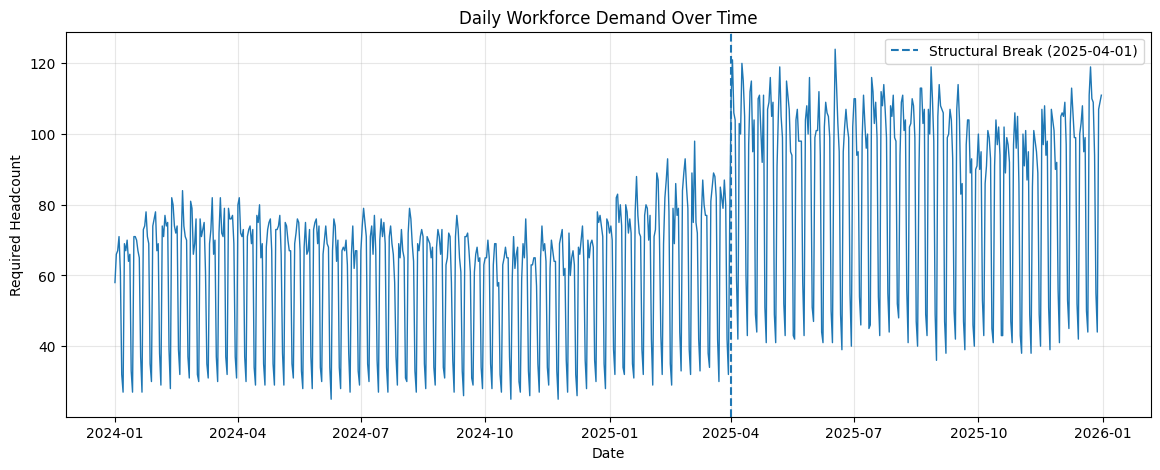

In [4]:
# Visualize daily workforce demand

plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["required_headcount"],
    linewidth=1
)

plt.axvline(
    pd.Timestamp("2025-04-01"),
    linestyle="--",
    label="Structural Break (2025-04-01)"
)

plt.title("Daily Workforce Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Required Headcount")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Initial Time Series Observation

The workforce demand series shows a clear recurring pattern over time, suggesting strong seasonality.

A noticeable structural change appears around April 2025, where the overall workforce demand level increases. This change should be considered later when designing the backtesting strategy and comparing forecasting models.

### STL Decomposition

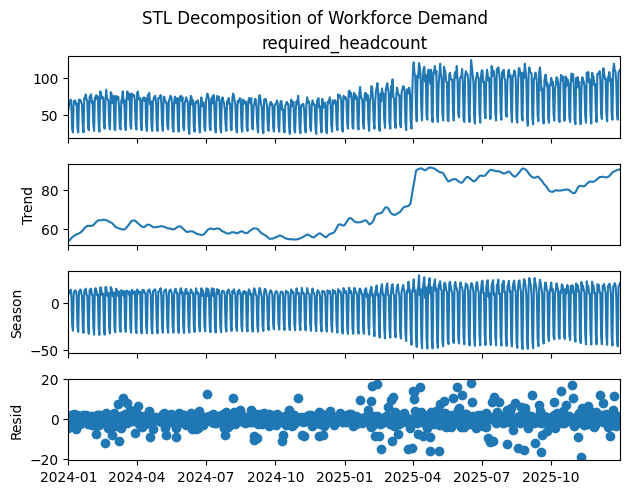

In [5]:
# STL decomposition with weekly seasonality

series = df.set_index("date")["required_headcount"]

stl = STL(series, period=7, robust=True)
stl_result = stl.fit()

stl_result.plot()
plt.suptitle("STL Decomposition of Workforce Demand", y=1.02)
plt.show()

### STL Interpretation

The decomposition shows a clear weekly seasonal pattern in workforce demand.

The trend is relatively stable during most of 2024, then increases noticeably around April 2025, which is consistent with the structural break identified in the dataset.

The residual component remains centered around zero, although the variability appears larger after the structural change.

### Autocorrelation Analysis (ACF & PACF)

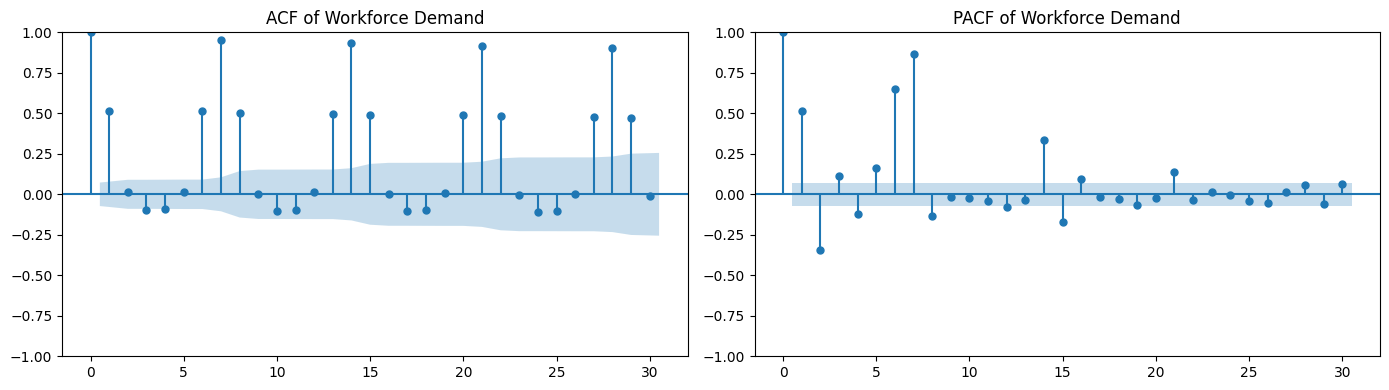

In [6]:
# ACF and PACF plots

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title("ACF of Workforce Demand")

plot_pacf(series, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Workforce Demand")

plt.tight_layout()
plt.show()

### ACF & PACF Interpretation

The ACF shows strong spikes at approximately 7-day intervals, indicating a clear weekly seasonal pattern in workforce demand.

The PACF also shows significant relationships at several lags, including around the weekly lag, suggesting that past workforce demand values contain useful predictive information.

Because the series also contains a trend and a structural break, the ARIMA parameters will not be selected from these plots alone. Stationarity will be checked first using the ADF test.

### Stationarity Test (ADF)

In [7]:
# Augmented Dickey-Fuller test

adf_result = adfuller(series.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.5633943024186311
p-value: 0.8790407662672464

Critical Values:
1%: -3.439593802573824
5%: -2.865619356068967
10%: -2.568942332870462


### ADF Interpretation

The ADF test returned a p-value of approximately 0.879, which is greater than 0.05.

Therefore, the null hypothesis of a unit root cannot be rejected, indicating that the original workforce demand series is non-stationary.

This is consistent with the observed trend and the structural change around April 2025. Differencing will therefore be applied before fitting ARIMA-type models.

### First Differencing

In [8]:
# First-order differencing

diff_series = series.diff().dropna()

adf_diff = adfuller(diff_series)

print("ADF Statistic after differencing:", adf_diff[0])
print("p-value after differencing:", adf_diff[1])

ADF Statistic after differencing: -8.210924538810847
p-value after differencing: 6.822098757722973e-13


### Differencing Interpretation

After applying first-order differencing, the ADF test returned a very small p-value (approximately 6.82e-13), which is well below 0.05.

This indicates that the differenced series is stationary. Therefore, first-order differencing is sufficient, supporting the use of `d = 1` in ARIMA-based models.

## 2. Classical Forecasting Model
### SARIMA Model

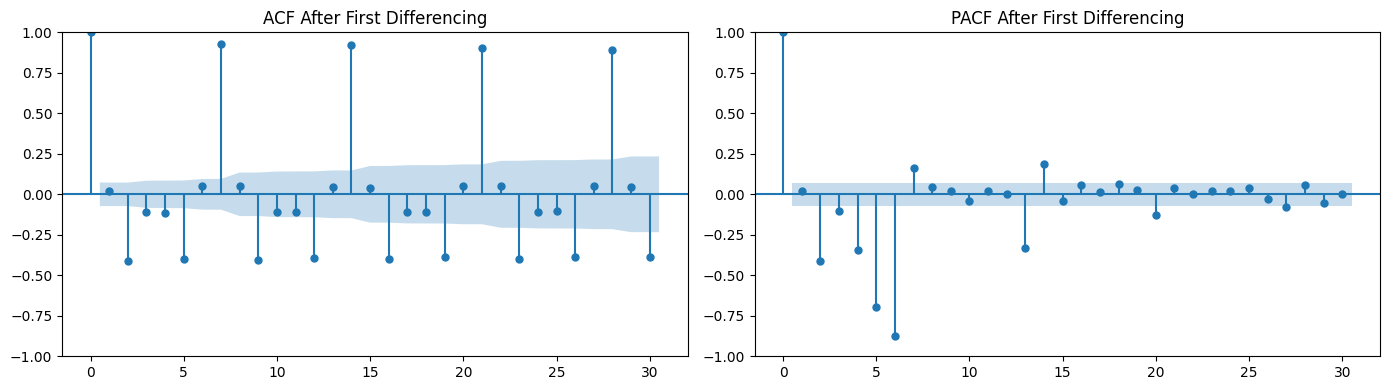

In [9]:
# ACF and PACF after first differencing

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(diff_series, lags=30, ax=axes[0])
axes[0].set_title("ACF After First Differencing")

plot_pacf(diff_series, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF After First Differencing")

plt.tight_layout()
plt.show()

### Parameter Selection Rationale

The first-order differenced series still shows strong autocorrelation at weekly lags (7, 14, 21, and 28), indicating that weekly seasonality remains important.

Therefore, SARIMA models with a seasonal period of 7 will be evaluated. Since `d = 1` was supported by the ADF test, a small set of low-order candidate models will be compared using AIC before selecting the final specification.

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [11]:
# Compare a small set of SARIMA candidate models

candidates = [
    ((1, 1, 1), (1, 0, 1, 7)),
    ((1, 1, 1), (1, 1, 1, 7)),
    ((0, 1, 1), (1, 1, 1, 7)),
    ((1, 1, 0), (1, 1, 1, 7))
]

results = []

for order, seasonal_order in candidates:
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    results.append({
        "order": order,
        "seasonal_order": seasonal_order,
        "AIC": fitted.aic
    })

comparison = pd.DataFrame(results).sort_values("AIC")
comparison

,order,seasonal_order,AIC
1,"(1, 1, 1)","(1, 1, 1, 7)",4443.605266
2,"(0, 1, 1)","(1, 1, 1, 7)",4447.001895
0,"(1, 1, 1)","(1, 0, 1, 7)",4483.313630
3,"(1, 1, 0)","(1, 1, 1, 7)",4642.369193


### Model Selection

Among the evaluated candidates, SARIMA(1,1,1)(1,1,1,7) achieved the lowest AIC (approximately 4443.61).

It was therefore selected as the classical forecasting model for further residual diagnostics and evaluation.

In [12]:
# Fit the selected SARIMA model

selected_model = SARIMAX(
    series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = selected_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                required_headcount   No. Observations:                  731
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2216.803
Date:                           Tue, 22 Sep 2026   AIC                           4443.605
Time:                                   16:14:13   BIC                           4466.460
Sample:                               01-01-2024   HQIC                          4452.432
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1019      0.032      3.163      0.002       0.039       0.165
ma.L1         -0.8754      0.019    -47.108

In [13]:
# Ljung-Box test for residual autocorrelation

from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = sarima_fit.resid.dropna()

ljung_box = acorr_ljungbox(
    residuals,
    lags=[7, 14, 21],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
7,9.007552,0.252114
14,16.546042,0.281177
21,23.381795,0.323965


### Residual Diagnostics

The Ljung-Box test returned p-values greater than 0.05 at lags 7, 14, and 21.

Therefore, there is no statistically significant evidence of residual autocorrelation at these lags. This suggests that the selected SARIMA model captures the main temporal structure of the series reasonably well.

## 3. Machine Learning Forecasting & Feature Engineering
### LightGBM Model

Lag, rolling, and calendar features are created from historical observations to train a LightGBM forecasting model.

All lag and rolling features are constructed using past values only to avoid data leakage.

### Feature Engineering

In [14]:
# Create time-based features for LightGBM

ml_df = df.copy().sort_values("date").reset_index(drop=True)

# Calendar features
ml_df["day_of_week"] = ml_df["date"].dt.dayofweek
ml_df["month"] = ml_df["date"].dt.month
ml_df["day_of_month"] = ml_df["date"].dt.day

# Lag features
ml_df["lag_1"] = ml_df["required_headcount"].shift(1)
ml_df["lag_7"] = ml_df["required_headcount"].shift(7)
ml_df["lag_14"] = ml_df["required_headcount"].shift(14)

# Rolling features
# shift(1) ensures that the current day's target is not used
ml_df["rolling_mean_7"] = (
    ml_df["required_headcount"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

ml_df["rolling_mean_14"] = (
    ml_df["required_headcount"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

# Remove rows with NaN values created by lag/rolling features
ml_df = ml_df.dropna().reset_index(drop=True)

ml_df.head()

,date,required_headcount,day_of_week,month,day_of_month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
0,2024-01-15,71.0,0,1,15,27.0,69.0,58.0,56.571429,55.571429
1,2024-01-16,71.0,1,1,16,71.0,67.0,66.0,56.857143,56.500000
2,2024-01-17,70.0,2,1,17,71.0,70.0,67.0,57.428571,56.857143
3,2024-01-18,67.0,3,1,18,70.0,64.0,71.0,57.428571,57.071429
4,2024-01-19,65.0,4,1,19,67.0,66.0,61.0,57.857143,56.785714


In [15]:
feature_columns = [
    "day_of_week",
    "month",
    "day_of_month",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14"
]

print("Number of rows after feature engineering:", len(ml_df))
print("\nFeatures used:")
print(feature_columns)

ml_df[["date", "required_headcount"] + feature_columns].head(10)

Number of rows after feature engineering: 717

Features used:
['day_of_week', 'month', 'day_of_month', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14']


,date,required_headcount,day_of_week,month,day_of_month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
0,2024-01-15,71.0,0,1,15,27.0,69.0,58.0,56.571429,55.571429
1,2024-01-16,71.0,1,1,16,71.0,67.0,66.0,56.857143,56.500000
2,2024-01-17,70.0,2,1,17,71.0,70.0,67.0,57.428571,56.857143
3,2024-01-18,67.0,3,1,18,70.0,64.0,71.0,57.428571,57.071429
4,2024-01-19,65.0,4,1,19,67.0,66.0,61.0,57.857143,56.785714
5,2024-01-20,37.0,5,1,20,65.0,33.0,32.0,57.714286,57.071429
6,2024-01-21,27.0,6,1,21,37.0,27.0,27.0,58.285714,57.428571
7,2024-01-22,73.0,0,1,22,27.0,71.0,69.0,58.285714,57.428571
8,2024-01-23,74.0,1,1,23,73.0,71.0,67.0,58.571429,57.714286
9,2024-01-24,78.0,2,1,24,74.0,70.0,70.0,59.000000,58.214286


### Feature Engineering Summary

Calendar, lag, and rolling features were created to represent temporal patterns and recent workforce demand.

The lag and rolling features use historical values only. The rolling statistics are shifted by one day so that the current target value is never used as an input feature, preventing data leakage.

In [16]:
# Install LightGBM if needed
!pip -q install lightgbm

In [17]:
from lightgbm import LGBMRegressor

X = ml_df[feature_columns]
y = ml_df["required_headcount"]

lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbosity=-1
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (717, 8)
Target shape: (717,)


## 4. Backtesting Framework & Time-Based Validation

An expanding-window walk-forward validation strategy is used to preserve the chronological order of the data.

At each fold, the training set includes all observations available up to that point, while validation is performed only on future observations.

This approach avoids leakage and allows model performance to be evaluated across different periods, including the structural change observed in 2025.

In [20]:
# Leakage-safe recursive walk-forward backtesting

from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

forecast_horizon = 30

# Validation periods selected to assess behavior
# before, around, and after the structural break
fold_dates = [
    pd.Timestamp("2025-02-01"),  # before structural break
    pd.Timestamp("2025-04-01"),  # structural break period
    pd.Timestamp("2025-10-01")   # after structural break
]

def make_training_features(data):
    temp = data.copy().sort_values("date").reset_index(drop=True)

    temp["day_of_week"] = temp["date"].dt.dayofweek
    temp["month"] = temp["date"].dt.month
    temp["day_of_month"] = temp["date"].dt.day

    temp["lag_1"] = temp["required_headcount"].shift(1)
    temp["lag_7"] = temp["required_headcount"].shift(7)
    temp["lag_14"] = temp["required_headcount"].shift(14)

    temp["rolling_mean_7"] = (
        temp["required_headcount"].shift(1).rolling(7).mean()
    )

    temp["rolling_mean_14"] = (
        temp["required_headcount"].shift(1).rolling(14).mean()
    )

    return temp.dropna().reset_index(drop=True)


def recursive_forecast(train_raw, test_dates):
    train_features = make_training_features(train_raw)

    X_train = train_features[feature_columns]
    y_train = train_features["required_headcount"]

    model = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    # Only information available before the forecast starts
    history = train_raw["required_headcount"].tolist()
    predictions = []

    for current_date in test_dates:

        row = pd.DataFrame([{
            "day_of_week": current_date.dayofweek,
            "month": current_date.month,
            "day_of_month": current_date.day,
            "lag_1": history[-1],
            "lag_7": history[-7],
            "lag_14": history[-14],
            "rolling_mean_7": np.mean(history[-7:]),
            "rolling_mean_14": np.mean(history[-14:])
        }])

        prediction = model.predict(row[feature_columns])[0]

        predictions.append(prediction)

        # Use prediction, not the unseen actual value
        history.append(prediction)

    return np.array(predictions)


backtest_results = []

for fold, test_start in enumerate(fold_dates, start=1):

    train_raw = df[df["date"] < test_start].copy()

    test_raw = df[
        (df["date"] >= test_start) &
        (df["date"] < test_start + pd.Timedelta(days=forecast_horizon))
    ].copy()

    predictions = recursive_forecast(
        train_raw,
        test_raw["date"].tolist()
    )

    y_true = test_raw["required_headcount"].values

    mae = mean_absolute_error(y_true, predictions)
    rmse = mean_squared_error(y_true, predictions) ** 0.5

    backtest_results.append({
        "fold": fold,
        "train_end": train_raw["date"].max(),
        "test_start": test_raw["date"].min(),
        "test_end": test_raw["date"].max(),
        "MAE": mae,
        "RMSE": rmse
    })

backtest_df = pd.DataFrame(backtest_results)

backtest_df

,fold,train_end,test_start,test_end,MAE,RMSE
0,1,2025-01-31,2025-02-01,2025-03-02,7.210865,8.907997
1,2,2025-03-31,2025-04-01,2025-04-30,25.590793,27.290398
2,3,2025-09-30,2025-10-01,2025-10-30,4.056569,5.360103


In [21]:
print("Average MAE:", backtest_df["MAE"].mean())
print("Average RMSE:", backtest_df["RMSE"].mean())

Average MAE: 12.286075531354408
Average RMSE: 13.852832799262027


### Backtesting Interpretation

The LightGBM model shows different performance across the three validation periods.

Performance is relatively stable before and after the structural break. However, the second fold, which begins on April 1, 2025, shows a substantial increase in both MAE and RMSE.

This indicates that the structural break had a strong impact on forecasting accuracy. Since the model was trained only on observations from the previous regime, it could not anticipate the sudden shift in workforce demand.

The results highlight why evaluating a forecasting model across multiple time periods is more informative than relying on a single train/test split.

### SARIMA Walk-Forward Backtesting

In [22]:
# SARIMA walk-forward backtesting using the same folds

sarima_backtest_results = []

for fold, test_start in enumerate(fold_dates, start=1):

    train_raw = df[df["date"] < test_start].copy()

    test_raw = df[
        (df["date"] >= test_start) &
        (df["date"] < test_start + pd.Timedelta(days=forecast_horizon))
    ].copy()

    train_series = train_raw.set_index("date")["required_headcount"]

    sarima_model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit_fold = sarima_model.fit(disp=False)

    forecast = sarima_fit_fold.forecast(steps=len(test_raw))

    y_true = test_raw["required_headcount"].values
    y_pred = forecast.values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    sarima_backtest_results.append({
        "fold": fold,
        "train_end": train_raw["date"].max(),
        "test_start": test_raw["date"].min(),
        "test_end": test_raw["date"].max(),
        "MAE": mae,
        "RMSE": rmse
    })

sarima_backtest_df = pd.DataFrame(sarima_backtest_results)

sarima_backtest_df

,fold,train_end,test_start,test_end,MAE,RMSE
0,1,2025-01-31,2025-02-01,2025-03-02,5.998259,7.179555
1,2,2025-03-31,2025-04-01,2025-04-30,20.031090,22.035146
2,3,2025-09-30,2025-10-01,2025-10-30,6.812584,8.081745


In [23]:
print("Average SARIMA MAE:", sarima_backtest_df["MAE"].mean())
print("Average SARIMA RMSE:", sarima_backtest_df["RMSE"].mean())

Average SARIMA MAE: 10.947311178011697
Average SARIMA RMSE: 12.432148530371128


### SARIMA Backtesting Interpretation

SARIMA was evaluated using the same three walk-forward folds as LightGBM to ensure a consistent comparison.

The largest forecasting error also occurs during the fold starting on April 1, 2025, confirming that the structural break affects both forecasting approaches.

Across the three folds, SARIMA achieved lower average MAE and RMSE than LightGBM.

## 5. Evaluation Metrics & Reporting

### WAPE and Model Comparison

In [24]:
# Weighted Absolute Percentage Error

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

In [25]:
# Detailed LightGBM backtesting with WAPE

lgbm_metrics = []

for fold, test_start in enumerate(fold_dates, start=1):

    train_raw = df[df["date"] < test_start].copy()

    test_raw = df[
        (df["date"] >= test_start) &
        (df["date"] < test_start + pd.Timedelta(days=forecast_horizon))
    ].copy()

    predictions = recursive_forecast(
        train_raw,
        test_raw["date"].tolist()
    )

    y_true = test_raw["required_headcount"].values

    lgbm_metrics.append({
        "Model": "LightGBM",
        "Fold": fold,
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "WAPE": wape(y_true, predictions)
    })

lgbm_metrics_df = pd.DataFrame(lgbm_metrics)
lgbm_metrics_df

,Model,Fold,MAE,RMSE,WAPE
0,LightGBM,1,7.210865,8.907997,10.942132
1,LightGBM,2,25.590793,27.290398,27.886807
2,LightGBM,3,4.056569,5.360103,4.903186


In [26]:
# Detailed SARIMA backtesting with WAPE

sarima_metrics = []

for fold, test_start in enumerate(fold_dates, start=1):

    train_raw = df[df["date"] < test_start].copy()

    test_raw = df[
        (df["date"] >= test_start) &
        (df["date"] < test_start + pd.Timedelta(days=forecast_horizon))
    ].copy()

    train_series = train_raw.set_index("date")["required_headcount"]

    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    predictions = fitted.forecast(steps=len(test_raw)).values
    y_true = test_raw["required_headcount"].values

    sarima_metrics.append({
        "Model": "SARIMA",
        "Fold": fold,
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "WAPE": wape(y_true, predictions)
    })

sarima_metrics_df = pd.DataFrame(sarima_metrics)
sarima_metrics_df

,Model,Fold,MAE,RMSE,WAPE
0,SARIMA,1,5.998259,7.179555,9.102062
1,SARIMA,2,20.031090,22.035146,21.828286
2,SARIMA,3,6.812584,8.081745,8.234389


In [27]:
# Average performance across folds

all_metrics = pd.concat(
    [lgbm_metrics_df, sarima_metrics_df],
    ignore_index=True
)

model_comparison = (
    all_metrics
    .groupby("Model")[["MAE", "RMSE", "WAPE"]]
    .mean()
    .round(2)
)

model_comparison

,MAE,RMSE,WAPE
Model,,,
LightGBM,12.29,13.85,14.58
SARIMA,10.95,12.43,13.05


### Evaluation Summary

Across the three walk-forward folds, SARIMA achieved lower average MAE, RMSE, and WAPE than LightGBM.

The WAPE results indicate an average error of approximately 13.05% for SARIMA compared with 14.58% for LightGBM.

However, final model selection will also consider uncertainty estimation, interpretability, computational requirements, and the effect of the structural break.

## 6. Probabilistic Forecasting & Prediction Intervals
### SARIMA 95% Prediction Intervals

In [28]:
# Evaluate 95% SARIMA prediction intervals across the same backtesting folds

interval_results = []

for fold, test_start in enumerate(fold_dates, start=1):

    train_raw = df[df["date"] < test_start].copy()

    test_raw = df[
        (df["date"] >= test_start) &
        (df["date"] < test_start + pd.Timedelta(days=forecast_horizon))
    ].copy()

    train_series = train_raw.set_index("date")["required_headcount"]

    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast_result = fitted.get_forecast(steps=len(test_raw))

    mean_forecast = forecast_result.predicted_mean.values
    conf_int = forecast_result.conf_int(alpha=0.05)

    lower = conf_int.iloc[:, 0].values
    upper = conf_int.iloc[:, 1].values

    y_true = test_raw["required_headcount"].values

    coverage = np.mean(
        (y_true >= lower) & (y_true <= upper)
    ) * 100

    interval_width = np.mean(upper - lower)

    interval_results.append({
        "Fold": fold,
        "Coverage (%)": coverage,
        "Average Interval Width": interval_width
    })

interval_df = pd.DataFrame(interval_results)

interval_df

,Fold,Coverage (%),Average Interval Width
0,1,76.666667,16.993184
1,2,23.333333,18.464462
2,3,96.666667,26.544956


In [29]:
print("Nominal coverage: 95%")
print("Average empirical coverage:", interval_df["Coverage (%)"].mean())
print("Average interval width:", interval_df["Average Interval Width"].mean())

Nominal coverage: 95%
Average empirical coverage: 65.55555555555556
Average interval width: 20.667533768419844


### Prediction Interval Evaluation

The nominal prediction interval level was 95%, while the average empirical coverage across the three backtesting folds was approximately 65.56%.

Coverage varied substantially across periods. The second fold, which begins at the structural break on April 1, 2025, achieved only 23.33% coverage. This indicates that the model's uncertainty estimates were not able to account for the sudden change in workforce demand.

The third fold achieved coverage close to the nominal level, although with a wider prediction interval.

Overall, the results show that SARIMA prediction intervals are reasonably informative during more stable periods but become poorly calibrated when the underlying data-generating process changes abruptly.

### Prediction Interval Visualization

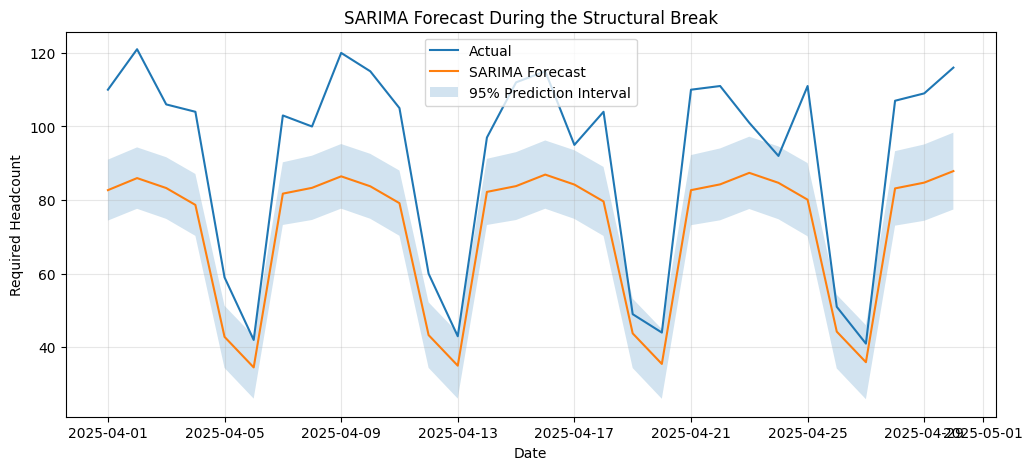

In [30]:
# Visualize the 95% prediction interval for the structural-break fold

test_start = pd.Timestamp("2025-04-01")

train_raw = df[df["date"] < test_start].copy()

test_raw = df[
    (df["date"] >= test_start) &
    (df["date"] < test_start + pd.Timedelta(days=forecast_horizon))
].copy()

train_series = train_raw.set_index("date")["required_headcount"]

model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted = model.fit(disp=False)

forecast_result = fitted.get_forecast(steps=len(test_raw))

forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

plt.figure(figsize=(12, 5))

plt.plot(
    test_raw["date"],
    test_raw["required_headcount"],
    label="Actual"
)

plt.plot(
    test_raw["date"],
    forecast_mean.values,
    label="SARIMA Forecast"
)

plt.fill_between(
    test_raw["date"],
    conf_int.iloc[:, 0].values,
    conf_int.iloc[:, 1].values,
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("SARIMA Forecast During the Structural Break")
plt.xlabel("Date")
plt.ylabel("Required Headcount")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7. Model Comparison & Final Recommendation

In [31]:
# Summary comparison of the forecasting approaches

decision_table = pd.DataFrame({
    "Criterion": [
        "MAE",
        "RMSE",
        "WAPE",
        "Interpretability",
        "Prediction Intervals",
        "Feature Engineering",
        "Computational Complexity",
        "Structural Break Performance"
    ],
    "SARIMA": [
        10.95,
        12.43,
        "13.05%",
        "High",
        "Native support",
        "Not required",
        "Relatively low",
        "Affected, but lower error in Fold 2"
    ],
    "LightGBM": [
        12.29,
        13.85,
        "14.58%",
        "Moderate",
        "Not included in this implementation",
        "Required",
        "Moderate",
        "More strongly affected in Fold 2"
    ]
})

decision_table

,Criterion,SARIMA,LightGBM
0,MAE,10.95,12.29
1,RMSE,12.43,13.85
2,WAPE,13.05%,14.58%
3,Interpretability,High,Moderate
4,Prediction Intervals,Native support,Not included in this implementation
5,Feature Engineering,Not required,Required
6,Computational Complexity,Relatively low,Moderate
7,Structural Break Performance,"Affected, but lower error in Fold 2",More strongly affected in Fold 2


### Model Comparison

SARIMA achieved lower average MAE, RMSE, and WAPE across the three walk-forward validation folds.

It also provides prediction intervals directly and requires less feature engineering than the LightGBM approach used in this project.

LightGBM was able to use lag, rolling, and calendar features effectively, but its recursive forecasts were more strongly affected by the structural break.

Both models experienced a clear degradation in performance during the April 2025 regime change, showing that sudden structural changes remain difficult to forecast from historical data alone.

### Final Recommendation

For this workforce demand series, SARIMA is selected as the final forecasting model.

The decision is based not only on its lower forecasting errors, but also on its interpretability, direct support for prediction intervals, relatively low computational requirements, and its ability to represent the strong weekly seasonal structure observed in the data.

However, the low interval coverage during the structural break shows that the model should be monitored and recalibrated when major changes in workforce demand occur.

### Final 30-Day Workforce Forecast

In [32]:
# Fit the selected SARIMA model on the full dataset

final_series = df.set_index("date")["required_headcount"]

final_model = SARIMAX(
    final_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

# Forecast the next 30 days
future_forecast = final_fit.get_forecast(steps=30)

forecast_mean = future_forecast.predicted_mean
forecast_interval = future_forecast.conf_int(alpha=0.05)

future_dates = pd.date_range(
    start=df["date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

final_forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast": forecast_mean.values,
    "lower_95": forecast_interval.iloc[:, 0].values,
    "upper_95": forecast_interval.iloc[:, 1].values
})

final_forecast_df.head(10)

,date,forecast,lower_95,upper_95
0,2026-01-01,104.092527,93.551942,114.633111
1,2026-01-02,99.925159,89.117592,110.732725
2,2026-01-03,55.745695,44.826632,66.664758
3,2026-01-04,46.666690,35.648889,57.684491
4,2026-01-05,107.706688,96.592166,118.821211
5,2026-01-06,110.976527,99.766233,122.186822
6,2026-01-07,110.677003,99.371759,121.982247
7,2026-01-08,104.769534,92.999136,116.539932
8,2026-01-09,100.705531,88.787040,112.624022
9,2026-01-10,56.535807,44.492414,68.579200


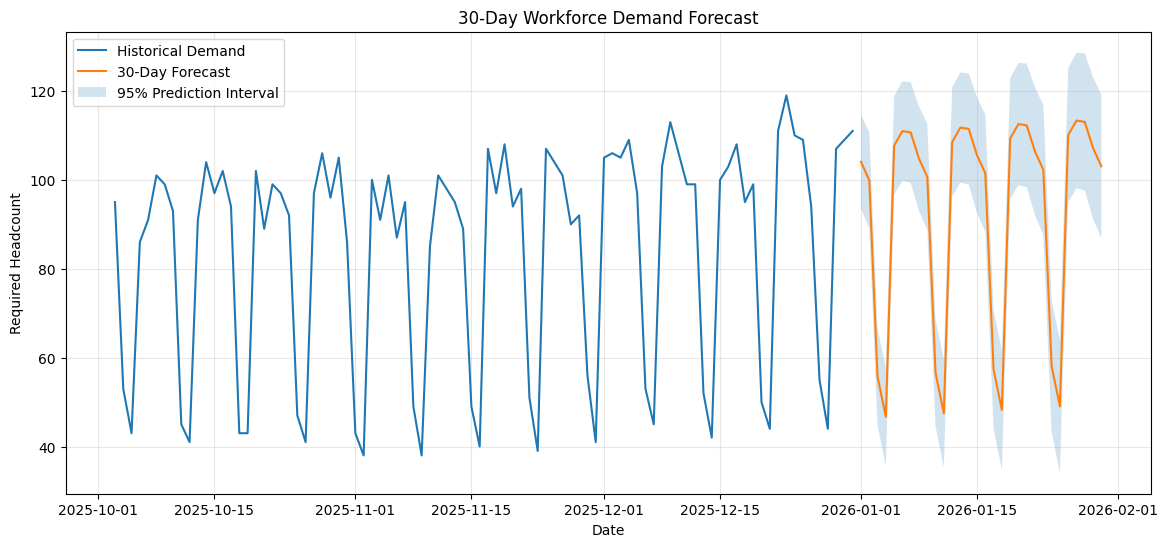

In [33]:
plt.figure(figsize=(14, 6))

# Show recent historical data
recent_history = df.tail(90)

plt.plot(
    recent_history["date"],
    recent_history["required_headcount"],
    label="Historical Demand"
)

# Forecast
plt.plot(
    final_forecast_df["date"],
    final_forecast_df["forecast"],
    label="30-Day Forecast"
)

# Prediction interval
plt.fill_between(
    final_forecast_df["date"],
    final_forecast_df["lower_95"],
    final_forecast_df["upper_95"],
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("30-Day Workforce Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Required Headcount")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Final Forecast Interpretation

The final SARIMA model was fitted using the complete historical dataset and used to forecast workforce demand for the next 30 days.

The forecast preserves the strong weekly seasonal pattern observed in the historical data. The 95% prediction intervals widen slightly over the forecast horizon, reflecting increasing uncertainty for observations further into the future.

Because the backtesting analysis showed reduced reliability during the structural break, these forecasts should be monitored and updated if a similar change in workforce demand occurs.